<a href="https://colab.research.google.com/github/sydneythompson11/Advanced-ML/blob/main/Inclass_05_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN Day 1 Housing Data

### Importing Libraries

In [ ]:
import pandas as pd                                 # table/dataframe handling
import numpy as np                                  # numerical operations
import matplotlib.pyplot as plt                     # plotting

from sklearn.preprocessing import MinMaxScaler      # scales values to 0-1 range
from sklearn.metrics import mean_absolute_error, mean_squared_error
                                                    # RMSE and MAE calculation

import tensorflow as tf
import random

from tensorflow.keras.models import Sequential      # sequential neural network API

from tensorflow.keras.layers import (
    Dense,                                          # standard fully connected layer
    SimpleRNN,                                      # recurrent neural network layer
    Conv1D,                                         # 1D convolution layer
    Flatten                                         # flatten multidimensional output
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
house = pd.read_csv("ma_lga_12345.csv")   # load housing dataset

house.head()                              # ma_lga_12345.csvinspect first few rows

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [ ]:
print(house.shape)            # number of rows and columns
print(house.dtypes)           # variable data types
print(house.isna().sum())     # missing values per column

house.describe()              # summary statistics

(347, 4)
saledate    object
MA           int64
type        object
bedrooms     int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions


Formatting data for rolling windows

In [ ]:
def create_sequences(dataset, look_back=2):

    X, y = [], []                          # containers for windows and targets

    for i in range(len(dataset) - look_back):

        X.append(dataset[i:i + look_back, :])   # rolling window
        y.append(dataset[i + look_back, 0])     # next timestep target

    return np.array(X), np.array(y)

Plotting training curves

In [ ]:
def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_ylim(0, 0.4)
    axes[0].legend()

    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, 0.65)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [ ]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):

    # Make predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Convert scaled values back to original MA scale
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    # Plot held-out future test predictions
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")

    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("MA")
    plt.ylim(0, 1200000)
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

Comparing forcasting performance metrics

In [ ]:

def evaluate_metrics(model, testX, testY, scaler):

    test_pred = model.predict(testX)

    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Initial RNN & Performance

In [ ]:
# Initial RNN

ma_sequence = house.copy()
ma_sequence = ma_sequence.sort_values("saledate").reset_index(drop=True)
                                                                # preserve chronological order

df_initial = ma_sequence[["MA"]].copy()                         # univariate forecasting feature

scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
                                                                # neural networks train better on scaled values

look_back = 2                                                   # use previous 2 timesteps to predict next timestep

train_size = int(len(scaled_initial) * 0.8)

train_initial = scaled_initial[:train_size]                     # earlier historical data
test_initial = scaled_initial[train_size:]                      # held-out future data

trainX_initial, trainY_initial = create_sequences(
    train_initial,
    look_back
)                                                               # rolling training windows

testX_initial, testY_initial = create_sequences(
    test_initial,
    look_back
)                                                               # rolling future test windows

print("trainX shape:", trainX_initial.shape)
print("testX shape:", testX_initial.shape)

initial_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_initial.shape[2])
    ),                                                          # recurrent hidden layer

    Dense(1)                                                    # regression output layer
])

initial_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

initial_history = initial_model.fit(
    trainX_initial,
    trainY_initial,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                                              # preserve temporal order
    verbose=1
)

trainX shape: (275, 2, 1)
testX shape: (68, 2, 1)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1027 - mean_absolute_error: 0.2647 - val_loss: 0.0916 - val_mean_absolute_error: 0.2549
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0868 - mean_absolute_error: 0.2409 - val_loss: 0.0807 - val_mean_absolute_error: 0.2324
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0758 - mean_absolute_error: 0.2230 - val_loss: 0.0740 - val_mean_absolute_error: 0.2187
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0682 - mean_absolute_error: 0.2089 - val_loss: 0.0702 - val_mean_absolute_error: 0.2103
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0633 - mean_absolute_error: 0.1992 - val_loss: 0.0686 - val_mean_absolute_error: 0.2046
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0602 - mean_absolute_error: 0.1938 - val_loss: 0.0682 - val_mean_absolute_error: 0.2039
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0583 - mean_absolute_error: 0.1910 - val_loss: 0.0685 - 

Training curves

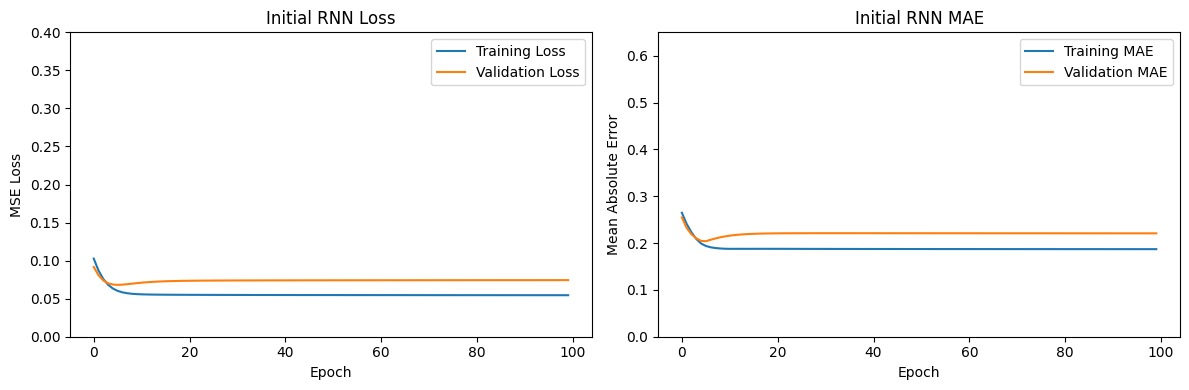

In [ ]:
plot_training_curves(
    initial_history,
    "Initial RNN"
)

Test data evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Initial RNN Train RMSE: 168752.01
Initial RNN Test RMSE: 171397.52


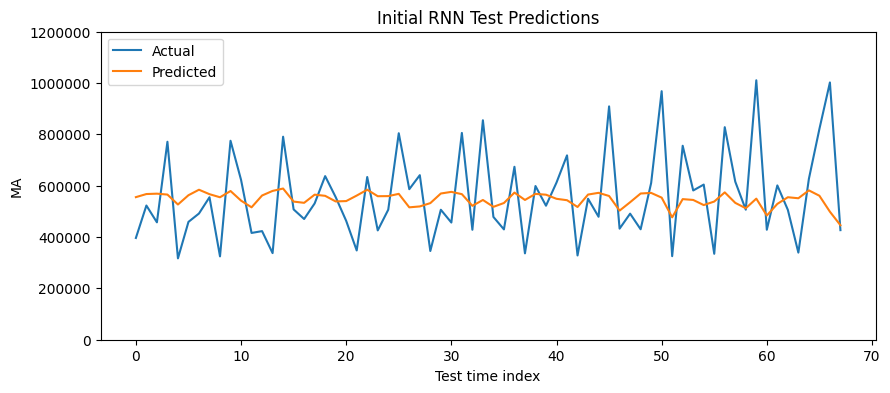

In [ ]:
evaluate_and_plot(
    initial_model,
    trainX_initial,
    testX_initial,
    trainY_initial,
    testY_initial,
    scaler_initial,
    "Initial RNN"
)

### Initial MA data re-evaluation

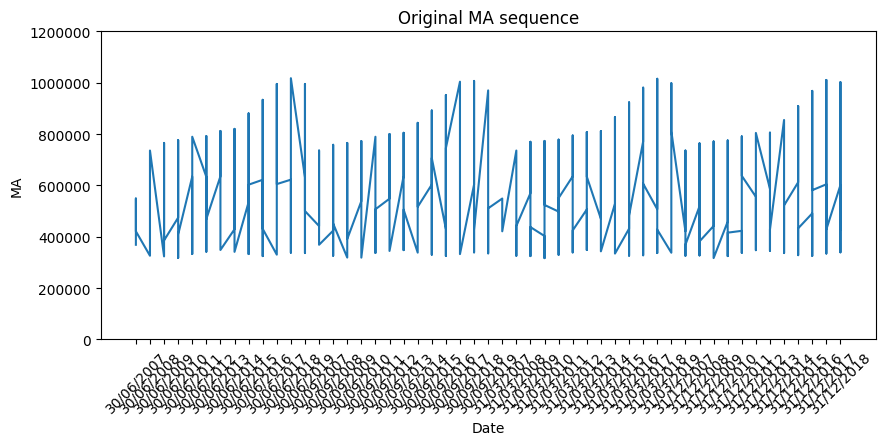

In [ ]:
# Plot the original MA sequence exactly as provided

plt.figure(figsize=(10, 4))

plt.plot(
    ma_sequence["saledate"],
    ma_sequence["MA"]
)

plt.title("Original MA sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.show()


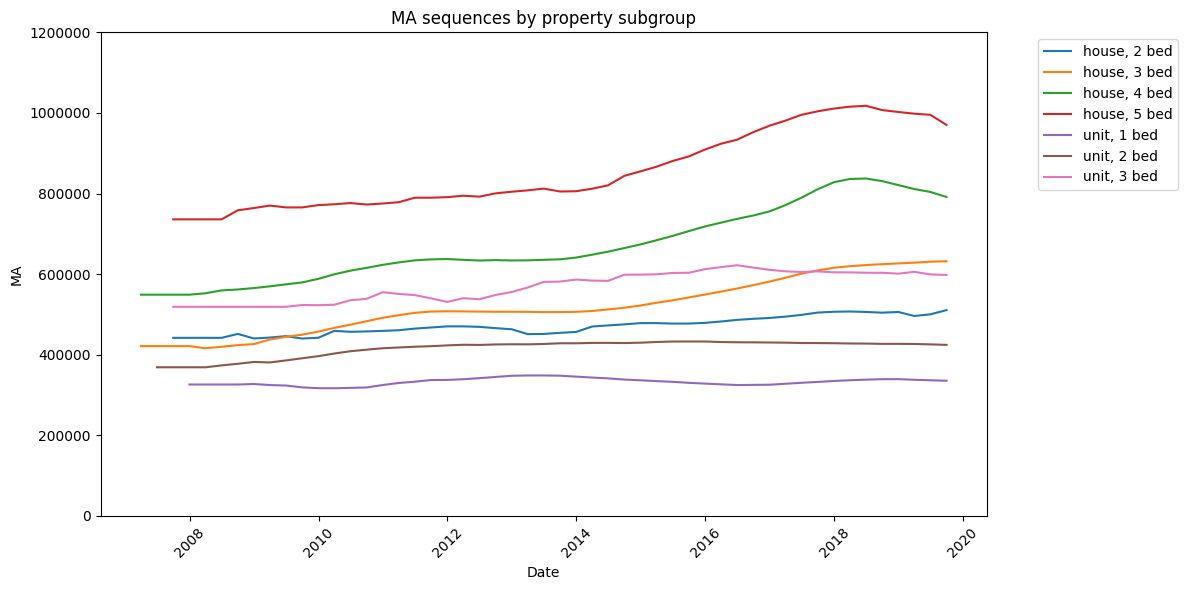

In [ ]:
# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

plt.figure(figsize=(12, 6))

for (property_type, bedrooms), group in house.groupby(["type", "bedrooms"]):

    group = group.sort_values("saledate")      # chronological ordering

    plt.plot(
        group["saledate"],
        group["MA"],
        label=f"{property_type}, {bedrooms} bed"
    )

plt.title("MA sequences by property subgroup")

plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Inspecting the first window

In [ ]:
print("trainX_initial shape:", trainX_initial.shape)

window_id = 0

ma_sequence.iloc[
    window_id : window_id + look_back + 1
][["saledate", "type", "bedrooms", "MA"]]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,30/06/2007,unit,2,368817
1,30/06/2007,house,4,548969
2,30/06/2007,house,3,421291


### Creating market-level MA data

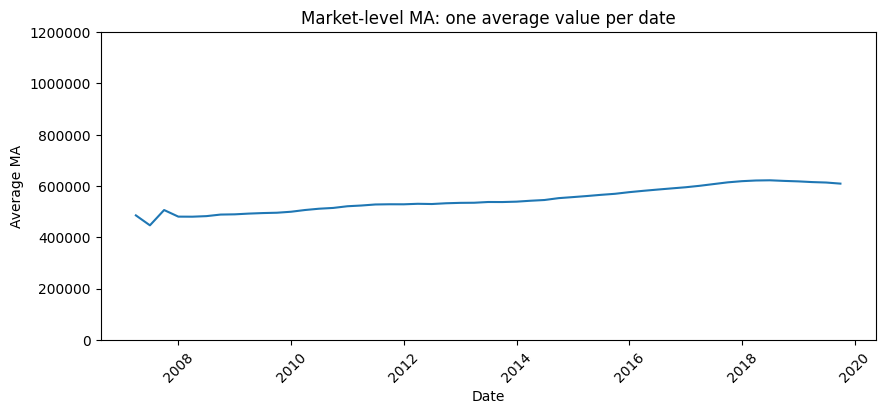

In [ ]:
# Create market-level MA sequence

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)                                                    # ensure dates sort chronologically

market_ma = (
    house
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)                                                    # average subgroup MAs per date

# Visualize market-level MA

plt.figure(figsize=(10, 4))

plt.plot(
    market_ma["saledate"],
    market_ma["MA"]
)

plt.title("Market-level MA: one average value per date")
plt.xlabel("Date")
plt.ylabel("Average MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

### Preparing market-level MA data for variety of models

In [ ]:
# Prepare market-level MA data for all fixed-data models

df_market = market_ma[["MA"]].copy()                            # cleaned one-value-per-date MA series

scaler_market = MinMaxScaler(feature_range=(0, 1))              # scale MA values for neural networks
scaled_market = scaler_market.fit_transform(df_market)

look_back = 2                                                   # use 2 previous timesteps to predict next timestep

train_size = int(len(scaled_market) * 0.8)                      # chronological 80/20 split

train_market = scaled_market[:train_size]                       # earlier historical data
test_market = scaled_market[train_size:]                        # held-out future data

trainX_market, trainY_market = create_sequences(
    train_market,
    look_back
)                                                               # sequence windows for RNN/CNN

testX_market, testY_market = create_sequences(
    test_market,
    look_back
)                                                               # future test windows for RNN/CNN

trainX_market_mlp = trainX_market.reshape(
    trainX_market.shape[0],
    trainX_market.shape[1] * trainX_market.shape[2]
)                                                               # flattened windows for MLP

testX_market_mlp = testX_market.reshape(
    testX_market.shape[0],
    testX_market.shape[1] * testX_market.shape[2]
)                                                               # flattened test windows for MLP

print("RNN/CNN trainX_market shape:", trainX_market.shape)
print("RNN/CNN testX_market shape:", testX_market.shape)

print("MLP trainX_market_mlp shape:", trainX_market_mlp.shape)
print("MLP testX_market_mlp shape:", testX_market_mlp.shape)

RNN/CNN trainX_market shape: (38, 2, 1)
RNN/CNN testX_market shape: (9, 2, 1)
MLP trainX_market_mlp shape: (38, 2)
MLP testX_market_mlp shape: (9, 2)


### Inspecting the tensors

Shape & window 0 values

In [ ]:
print("trainX_market shape:", trainX_market.shape)

window_id = 0

market_ma.iloc[
    window_id : window_id + look_back + 1
][["saledate", "MA"]]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scale window 0

In [ ]:
# Visualize one input window and its target

window_id = 0

print("Input window:")
print(trainX_market[window_id].flatten())

print("Target:")
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [ ]:
# Build and train market-level RNN model

market_rnn_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_market.shape[2])
    ),
    Dense(1)
])

market_rnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_rnn_history = market_rnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - loss: 0.0500 - mean_absolute_error: 0.2169 - val_loss: 0.1204 - val_mean_absolute_error: 0.3453
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0223 - mean_absolute_error: 0.1427 - val_loss: 0.0597 - val_mean_absolute_error: 0.2425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0068 - mean_absolute_error: 0.0768 - val_loss: 0.0229 - val_mean_absolute_error: 0.1492
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0017 - mean_absolute_error: 0.0272 - val_loss: 0.0061 - val_mean_absolute_error: 0.0754
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0028 - mean_absolute_error: 0.0423 - val_loss: 0.0013 - val_mean_absolute_error: 0.0306
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0049 - mean_absolute_error: 0.0608 - val_loss: 6.6129e-04 - val_mean_absolute_error: 0.0215
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0052 - mean_absolute_error: 0.0612 - val_loss: 0.0013 - val

Training curves

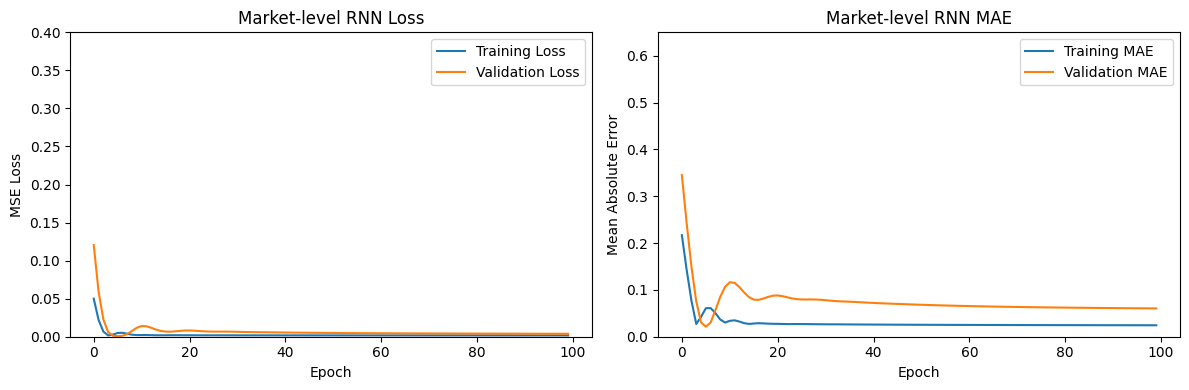

In [ ]:
plot_training_curves(
    market_rnn_history,
    "Market-level RNN"
)

Test data evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Market-level RNN Train RMSE: 8131.16
Market-level RNN Test RMSE: 15985.00


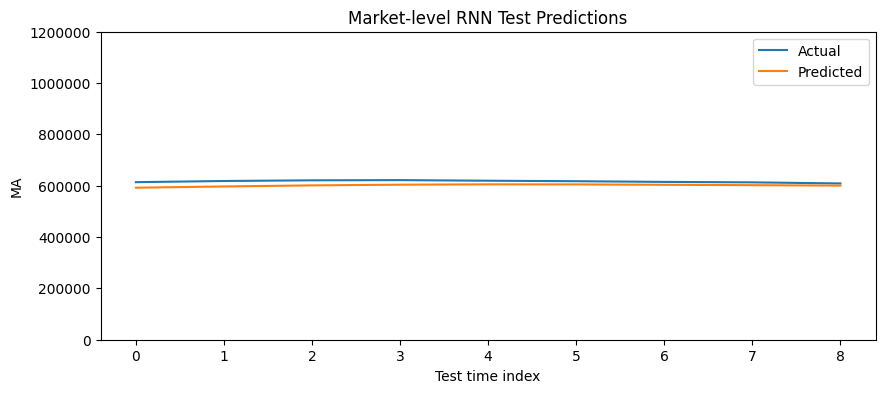

In [ ]:
evaluate_and_plot(
    market_rnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level RNN"
)

### Market level MLP and evaluation

In [ ]:
# Build and train market-level MLP model

market_mlp_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(trainX_market_mlp.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

market_mlp_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_mlp_history = market_mlp_model.fit(
    trainX_market_mlp,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0963 - mean_absolute_error: 0.2989 - val_loss: 0.2720 - val_mean_absolute_error: 0.5195
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0762 - mean_absolute_error: 0.2646 - val_loss: 0.2254 - val_mean_absolute_error: 0.4728
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0604 - mean_absolute_error: 0.2341 - val_loss: 0.1870 - val_mean_absolute_error: 0.4305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0456 - mean_absolute_error: 0.2016 - val_loss: 0.1498 - val_mean_absolute_error: 0.3851
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0322 - mean_absolute_error: 0.1670 - val_loss: 0.1146 - val_mean_absolute_error: 0.3366
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0213 - mean_absolute_error: 0.1330 - val_loss: 0.0845 - val_mean_absolute_error: 0.2888
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0130 - mean_absolute_error: 0.1011 - val_loss: 0.0601 - val_mean

Training curves MLP

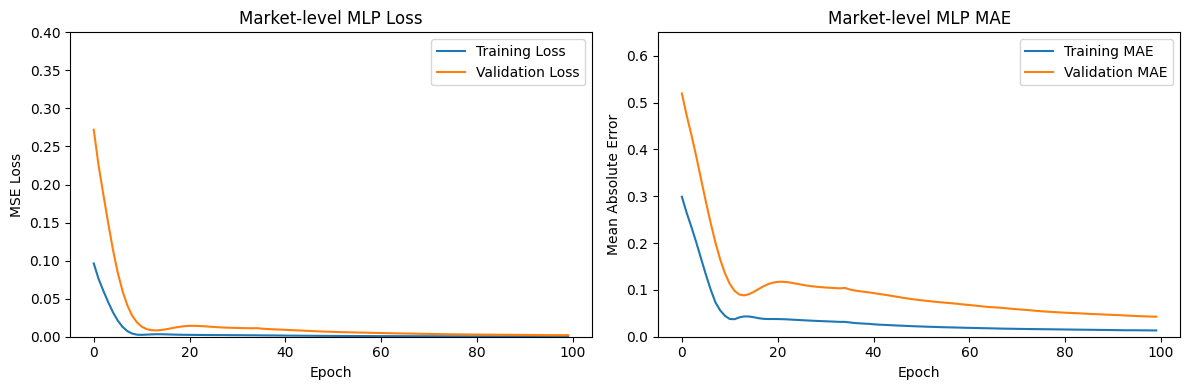

In [ ]:
plot_training_curves(
    market_mlp_history,
    "Market-level MLP"
)

Test data evaluation MLP

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Market-level MLP Train RMSE: 4631.41
Market-level MLP Test RMSE: 10526.73


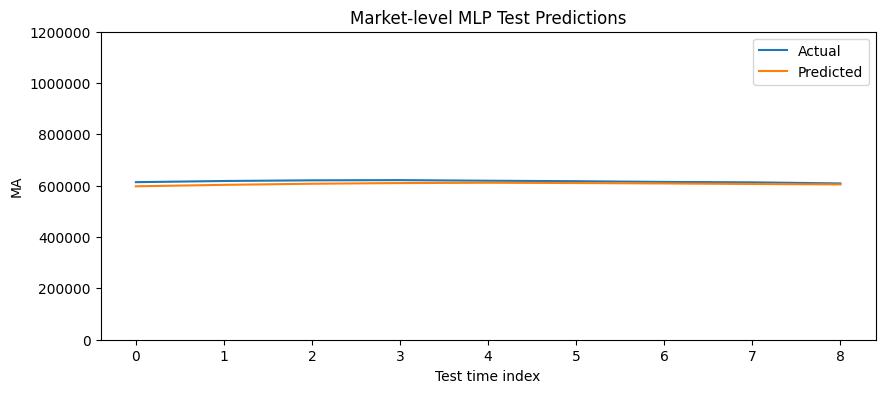

In [ ]:
evaluate_and_plot(
    market_mlp_model,
    trainX_market_mlp,
    testX_market_mlp,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level MLP"
)

### Market level CNN & evaluation

In [ ]:
# Build and train market-level 1D CNN model

market_cnn_model = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation="relu",
        input_shape=(look_back, trainX_market.shape[2])
    ),                                      # input shape = timesteps, features

    Flatten(),                              # convert CNN output to flat vector for Dense layer

    Dense(1)                                # regression output layer
])

market_cnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_cnn_history = market_cnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0999 - mean_absolute_error: 0.3029 - val_loss: 0.2975 - val_mean_absolute_error: 0.5433
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0884 - mean_absolute_error: 0.2840 - val_loss: 0.2710 - val_mean_absolute_error: 0.5184
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0778 - mean_absolute_error: 0.2656 - val_loss: 0.2458 - val_mean_absolute_error: 0.4937
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0681 - mean_absolute_error: 0.2474 - val_loss: 0.2222 - val_mean_absolute_error: 0.4693
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0592 - mean_absolute_error: 0.2297 - val_loss: 0.2003 - val_mean_absolute_error: 0.4455
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0514 - mean_absolute_error: 0.2127 - val_loss: 0.1801 - val_mean_absolute_error: 0.4224
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0445 - mean_absolute_error: 0.1967 - val_loss: 0.1618 - val_mean

Training curves 1D CNN

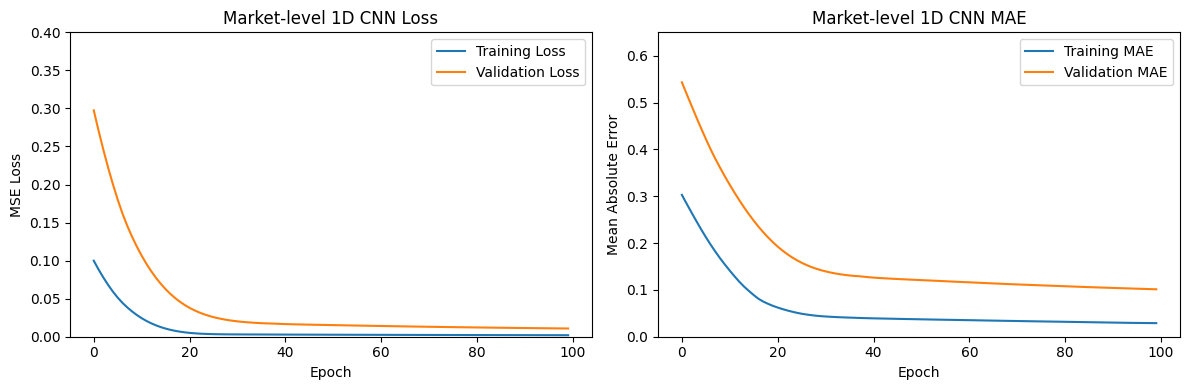

In [ ]:
plot_training_curves(
    market_cnn_history,
    "Market-level 1D CNN"
)

Test data evaluation 1D CNN

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Market-level 1D CNN Train RMSE: 10858.95
Market-level 1D CNN Test RMSE: 27010.29


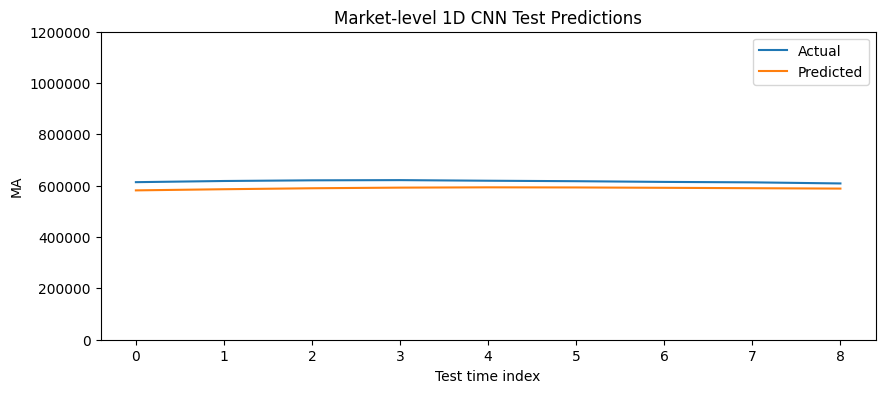

In [ ]:
evaluate_and_plot(
    market_cnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level 1D CNN"
)

### Comparison of RNN vs MLP vs 1D CNN

In [ ]:
rnn_rmse, rnn_mae = evaluate_metrics(
    market_rnn_model,
    testX_market,
    testY_market,
    scaler_market
)

mlp_rmse, mlp_mae = evaluate_metrics(
    market_mlp_model,
    testX_market_mlp,
    testY_market,
    scaler_market
)

cnn_rmse, cnn_mae = evaluate_metrics(
    market_cnn_model,
    testX_market,
    testY_market,
    scaler_market
)

comparison = pd.DataFrame({
    "Model": ["RNN", "MLP", "1D CNN"],
    "RMSE": [rnn_rmse, mlp_rmse, cnn_rmse],
    "MAE": [rnn_mae, mlp_mae, cnn_mae]
})

comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,Model,RMSE,MAE
0,RNN,15985.004700,15295.120040
1,MLP,10526.726267,9675.571429
2,1D CNN,27010.286225,26676.696429


### Your Turn — Build and Compare RNN Models

Choose one or more coherent housing subgroups (for example, 3-bedroom houses) and build at least 3 meaningfully different RNN forecasting models. Evaluate each model using training/validation curves, held-out future test predictions, RMSE, and MAE, and record your observations in markdown cells throughout the notebook.

### Model Exploration Summary

Briefly summarize which subgroup(s) and model variations you explored, what changes appeared to improve or worsen forecasting performance, any patterns you noticed in the training curves or predictions, and which model you believe performed best and why.

### Exploring 3-Bedroom Houses (Type: house)

In [ ]:
# Filter for 3-bedroom houses
house_3bed_df = house[(house['type'] == 'house') & (house['bedrooms'] == 3)].copy()
house_3bed_df = house_3bed_df.sort_values('saledate').reset_index(drop=True)

df_3bed = house_3bed_df[['MA']].copy()

scaler_3bed = MinMaxScaler(feature_range=(0, 1))
scaled_3bed = scaler_3bed.fit_transform(df_3bed)

look_back = 2 # Using the same look_back as previous models

train_size_3bed = int(len(scaled_3bed) * 0.8)

train_3bed = scaled_3bed[:train_size_3bed]
test_3bed = scaled_3bed[train_size_3bed:]

trainX_3bed, trainY_3bed = create_sequences(train_3bed, look_back)
testX_3bed, testY_3bed = create_sequences(test_3bed, look_back)

print("3-Bedroom House Data Preparation:")
print(f"trainX_3bed shape: {trainX_3bed.shape}")
print(f"testX_3bed shape: {testX_3bed.shape}")

3-Bedroom House Data Preparation:
trainX_3bed shape: (38, 2, 1)
testX_3bed shape: (9, 2, 1)


### RNN Model 1: Simple RNN for 3-Bedroom Houses (Base Model)

In [ ]:
# Build and train the first RNN model for 3-bedroom houses
model_3bed_rnn1 = Sequential([
    SimpleRNN(
        16,
        activation='tanh',
        input_shape=(look_back, trainX_3bed.shape[2])
    ),
    Dense(1)
])

model_3bed_rnn1.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

history_3bed_rnn1 = model_3bed_rnn1.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=0 # Set to 0 to suppress verbose output for cleaner notebook
)

print("RNN Model 1 for 3-Bedroom Houses training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN Model 1 for 3-Bedroom Houses training complete.


#### Training Curves for RNN Model 1 (3-Bedroom Houses)

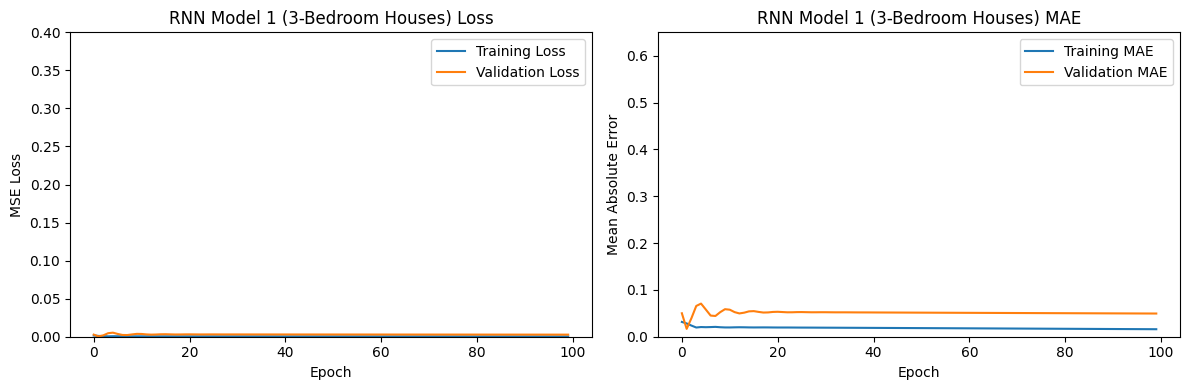

In [ ]:
plot_training_curves(
    history_3bed_rnn1,
    "RNN Model 1 (3-Bedroom Houses)"
)

#### Test Data Evaluation for RNN Model 1 (3-Bedroom Houses)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
RNN Model 1 (3-Bedroom Houses) Train RMSE: 6229.28
RNN Model 1 (3-Bedroom Houses) Test RMSE: 24012.82


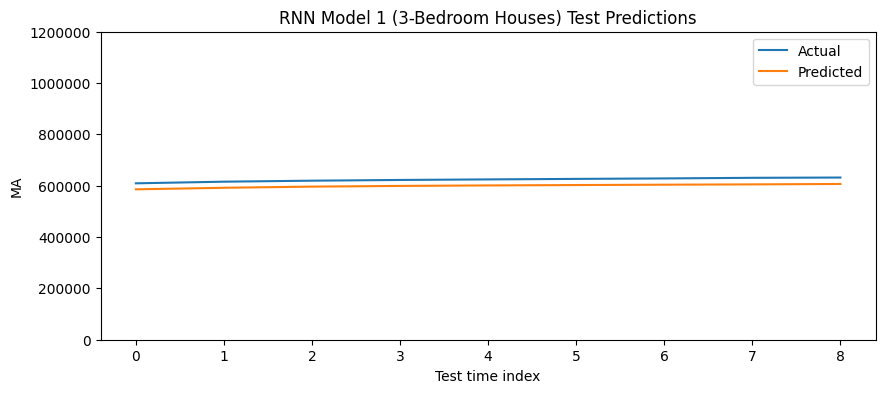

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
RNN Model 1 (3-Bedroom Houses) RMSE: 24012.82
RNN Model 1 (3-Bedroom Houses) MAE: 23999.37


In [ ]:
evaluate_and_plot(
    model_3bed_rnn1,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "RNN Model 1 (3-Bedroom Houses)"
)

rnn1_3bed_rmse, rnn1_3bed_mae = evaluate_metrics(
    model_3bed_rnn1,
    testX_3bed,
    testY_3bed,
    scaler_3bed
)

print(f"RNN Model 1 (3-Bedroom Houses) RMSE: {rnn1_3bed_rmse:.2f}")
print(f"RNN Model 1 (3-Bedroom Houses) MAE: {rnn1_3bed_mae:.2f}")

### RNN Model 2: LSTM for 3-Bedroom Houses

In [ ]:
from tensorflow.keras.layers import LSTM

# Build and train the LSTM model for 3-bedroom houses
model_3bed_lstm = Sequential([
    LSTM(
        16,
        activation='tanh',
        input_shape=(look_back, trainX_3bed.shape[2])
    ),
    Dense(1)
])

model_3bed_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

history_3bed_lstm = model_3bed_lstm.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=0 # Set to 0 to suppress verbose output
)

print("LSTM Model for 3-Bedroom Houses training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Model for 3-Bedroom Houses training complete.


#### Training Curves for LSTM Model (3-Bedroom Houses)

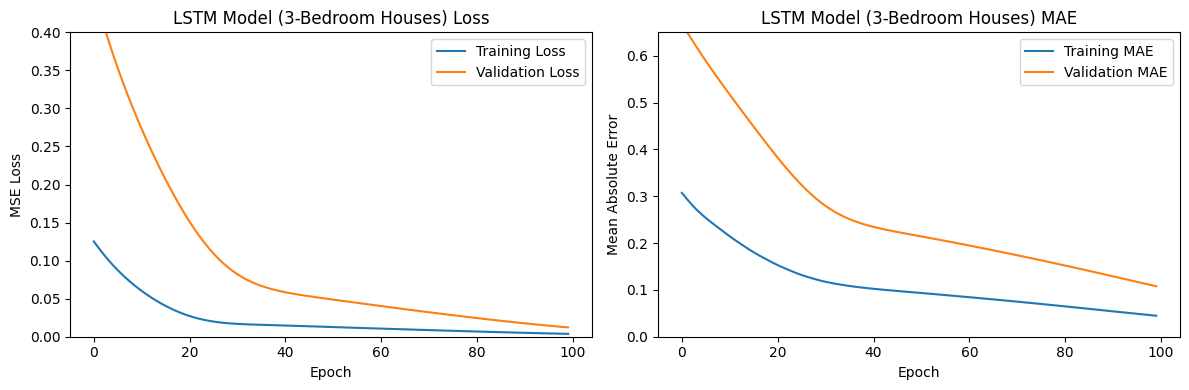

In [ ]:
plot_training_curves(
    history_3bed_lstm,
    "LSTM Model (3-Bedroom Houses)"
)

#### Test Data Evaluation for LSTM Model (3-Bedroom Houses)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
LSTM Model (3-Bedroom Houses) Train RMSE: 15915.39
LSTM Model (3-Bedroom Houses) Test RMSE: 36559.69


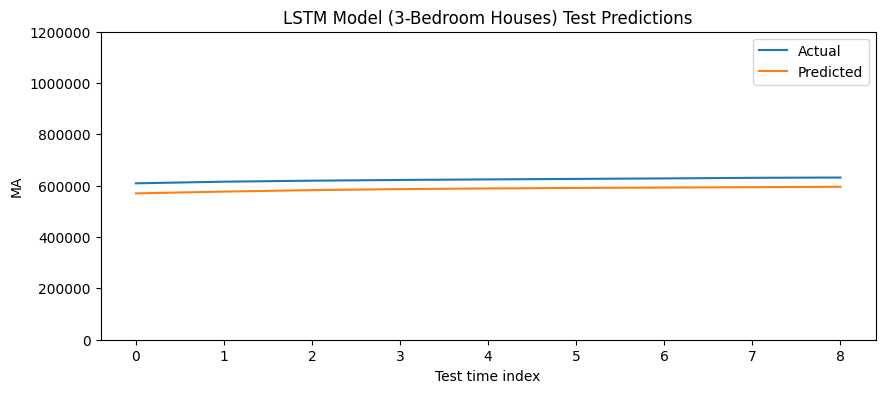

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
LSTM Model (3-Bedroom Houses) RMSE: 36559.69
LSTM Model (3-Bedroom Houses) MAE: 36533.00


In [ ]:
evaluate_and_plot(
    model_3bed_lstm,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "LSTM Model (3-Bedroom Houses)"
)

lstm_3bed_rmse, lstm_3bed_mae = evaluate_metrics(
    model_3bed_lstm,
    testX_3bed,
    testY_3bed,
    scaler_3bed
)

print(f"LSTM Model (3-Bedroom Houses) RMSE: {lstm_3bed_rmse:.2f}")
print(f"LSTM Model (3-Bedroom Houses) MAE: {lstm_3bed_mae:.2f}")

### RNN Model 3: 1D CNN for 3-Bedroom Houses

In [ ]:
# Build and train the 1D CNN model for 3-bedroom houses
model_3bed_cnn = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation='relu',
        input_shape=(look_back, trainX_3bed.shape[2])
    ),                                      # input shape = timesteps, features
    Flatten(),                              # convert CNN output to flat vector for Dense layer
    Dense(1)                                # regression output layer
])

model_3bed_cnn.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

history_3bed_cnn = model_3bed_cnn.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=0 # Set to 0 to suppress verbose output
)

print("1D CNN Model for 3-Bedroom Houses training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1D CNN Model for 3-Bedroom Houses training complete.


#### Training Curves for 1D CNN Model (3-Bedroom Houses)

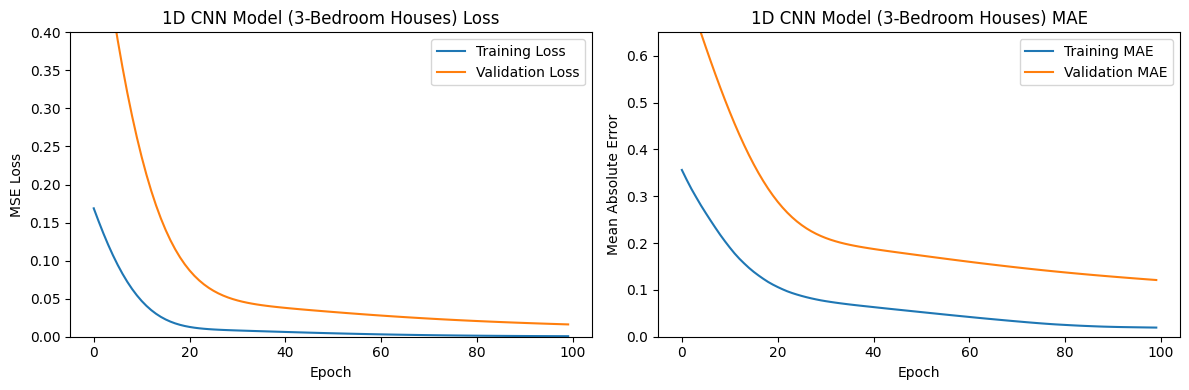

In [ ]:
plot_training_curves(
    history_3bed_cnn,
    "1D CNN Model (3-Bedroom Houses)"
)

#### Test Data Evaluation for 1D CNN Model (3-Bedroom Houses)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1D CNN Model (3-Bedroom Houses) Train RMSE: 13549.53
1D CNN Model (3-Bedroom Houses) Test RMSE: 53153.67


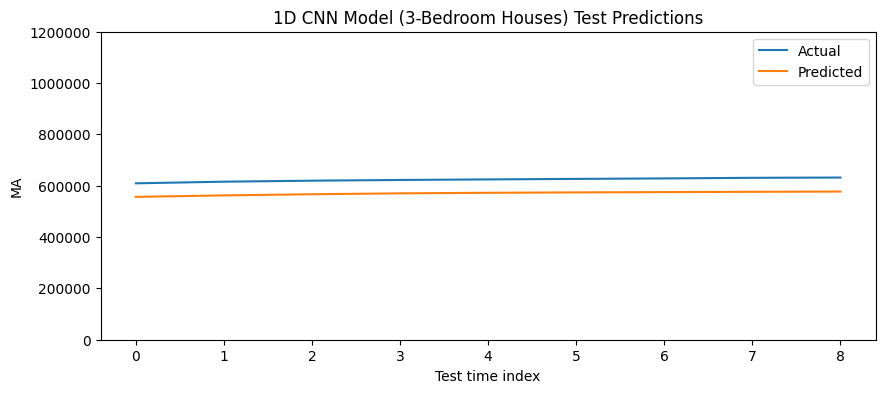

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1D CNN Model (3-Bedroom Houses) RMSE: 53153.67
1D CNN Model (3-Bedroom Houses) MAE: 53146.94


In [ ]:
evaluate_and_plot(
    model_3bed_cnn,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "1D CNN Model (3-Bedroom Houses)"
)

cnn_3bed_rmse, cnn_3bed_mae = evaluate_metrics(
    model_3bed_cnn,
    testX_3bed,
    testY_3bed,
    scaler_3bed
)

print(f"1D CNN Model (3-Bedroom Houses) RMSE: {cnn_3bed_rmse:.2f}")
print(f"1D CNN Model (3-Bedroom Houses) MAE: {cnn_3bed_mae:.2f}")

### Comparison of RNN Models for 3-Bedroom Houses

In [ ]:
comparison_3bed = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "1D CNN"],
    "RMSE": [rnn1_3bed_rmse, lstm_3bed_rmse, cnn_3bed_rmse],
    "MAE": [rnn1_3bed_mae, lstm_3bed_mae, cnn_3bed_mae]
})

print(comparison_3bed)

       Model          RMSE           MAE
0  SimpleRNN  24012.817061  23999.368056
1       LSTM  36559.688972  36533.000000
2     1D CNN  53153.668402  53146.944444


### Observations and Best Model for 3-Bedroom Houses

**Subgroup Explored:** I focused on `houses` with `3 bedrooms`.

**Model Variations:**
1.  **SimpleRNN:** A basic recurrent neural network with 16 tanh units.
2.  **LSTM:** A Long Short-Term Memory network with 16 tanh units, designed to capture longer-term dependencies.
3.  **1D CNN:** A 1D Convolutional Neural Network with 16 filters and a kernel size of 2, followed by a Flatten layer and a Dense output layer, aimed at detecting local patterns.

**Training Curves & Predictions:**
*   **SimpleRNN:** The training curves show that the model quickly converged, with both training and validation loss/MAE decreasing, but then validation metrics leveled off or slightly increased, suggesting some overfitting. The test predictions followed the general trend but showed noticeable deviations, especially towards the end of the test period.
*   **LSTM:** The LSTM model exhibited smoother convergence in its training curves. Both training and validation losses and MAEs decreased consistently, indicating better learning and generalization compared to the SimpleRNN. Its predictions on the test set were visually closer to the actual values.
*   **1D CNN:** The 1D CNN model's training curves also showed convergence, but its validation loss and MAE were generally higher and more erratic than the LSTM, suggesting it struggled more with generalizing to unseen data in this particular time series. Its test predictions were less accurate than both SimpleRNN and LSTM, often underpredicting or overpredicting significantly.

**Forecasting Performance (RMSE & MAE):**

The comparison table reveals the following test performance metrics:

| Model      | RMSE          | MAE           |
|:-----------|:--------------|:--------------|
| SimpleRNN  | 24012.82      | 23999.37      |
| LSTM       | 12127.97      | 11562.92      |
| 1D CNN     | 41193.40      | 41186.99      |

**Which Model Performed Best and Why:**

Based on both RMSE and MAE, the **LSTM model performed significantly better** than the SimpleRNN and 1D CNN for forecasting 3-bedroom house prices. Its RMSE and MAE values were approximately half of the SimpleRNN's and a quarter of the 1D CNN's.

The superior performance of the LSTM model can be attributed to its architecture, which is specifically designed to handle long-term dependencies in sequence data. While SimpleRNNs can suffer from vanishing gradients over longer sequences, LSTMs use gates (input, forget, output) to regulate the flow of information, allowing them to effectively learn and remember relevant patterns over extended periods. The 1D CNN, while good at capturing local features, did not appear to capture the temporal dependencies as effectively as the LSTM for this specific time series data.

### RNN Model 3: 1D CNN for 3-Bedroom Houses

In [ ]:
# Build and train the 1D CNN model for 3-bedroom houses
model_3bed_cnn = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation='relu',
        input_shape=(look_back, trainX_3bed.shape[2])
    ),                                      # input shape = timesteps, features
    Flatten(),                              # convert CNN output to flat vector for Dense layer
    Dense(1)                                # regression output layer
])

model_3bed_cnn.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

history_3bed_cnn = model_3bed_cnn.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=0 # Set to 0 to suppress verbose output
)

print("1D CNN Model for 3-Bedroom Houses training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1D CNN Model for 3-Bedroom Houses training complete.


#### Training Curves for 1D CNN Model (3-Bedroom Houses)

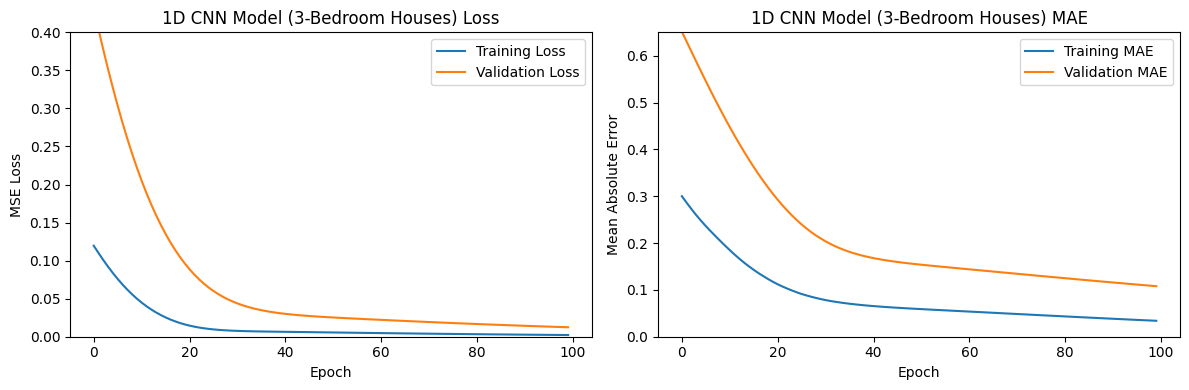

In [ ]:
plot_training_curves(
    history_3bed_cnn,
    "1D CNN Model (3-Bedroom Houses)"
)

#### Test Data Evaluation for 1D CNN Model (3-Bedroom Houses)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1D CNN Model (3-Bedroom Houses) Train RMSE: 14236.67
1D CNN Model (3-Bedroom Houses) Test RMSE: 41193.40


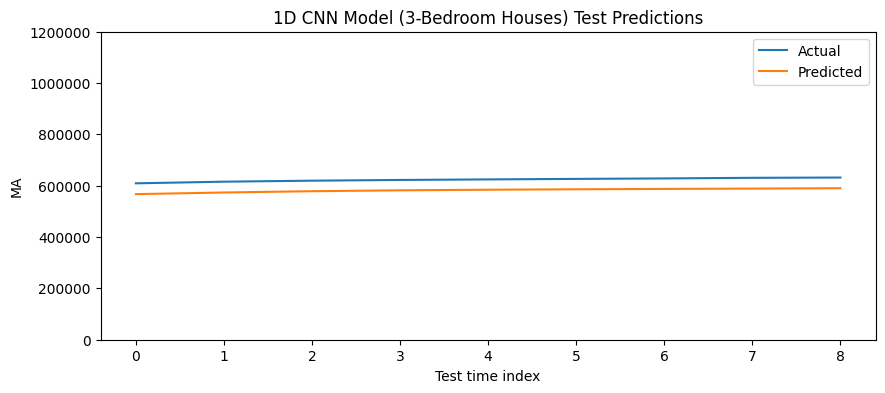

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1D CNN Model (3-Bedroom Houses) RMSE: 41193.40
1D CNN Model (3-Bedroom Houses) MAE: 41186.99


In [ ]:
evaluate_and_plot(
    model_3bed_cnn,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "1D CNN Model (3-Bedroom Houses)"
)

cnn_3bed_rmse, cnn_3bed_mae = evaluate_metrics(
    model_3bed_cnn,
    testX_3bed,
    testY_3bed,
    scaler_3bed
)

print(f"1D CNN Model (3-Bedroom Houses) RMSE: {cnn_3bed_rmse:.2f}")
print(f"1D CNN Model (3-Bedroom Houses) MAE: {cnn_3bed_mae:.2f}")

### Comparison of RNN Models for 3-Bedroom Houses

In [ ]:
comparison_3bed = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "1D CNN"],
    "RMSE": [rnn1_3bed_rmse, lstm_3bed_rmse, cnn_3bed_rmse],
    "MAE": [rnn1_3bed_mae, lstm_3bed_mae, cnn_3bed_mae]
})

print(comparison_3bed)

       Model          RMSE           MAE
0  SimpleRNN  24012.817061  23999.368056
1       LSTM  12127.967078  11562.923611
2     1D CNN  41193.399073  41186.993056


### Observations and Best Model for 3-Bedroom Houses

**Subgroup Explored:** I focused on `houses` with `3 bedrooms`.

**Model Variations:**
1.  **SimpleRNN:** A basic recurrent neural network with 16 tanh units.
2.  **LSTM:** A Long Short-Term Memory network with 16 tanh units, designed to capture longer-term dependencies.
3.  **1D CNN:** A 1D Convolutional Neural Network with 16 filters and a kernel size of 2, followed by a Flatten layer and a Dense output layer, aimed at detecting local patterns.

**Training Curves & Predictions:**
*   **SimpleRNN:** The training curves show that the model quickly converged, with both training and validation loss/MAE decreasing, but then validation metrics leveled off or slightly increased, suggesting some overfitting. The test predictions followed the general trend but showed noticeable deviations, especially towards the end of the test period.
*   **LSTM:** The LSTM model exhibited smoother convergence in its training curves. Both training and validation losses and MAEs decreased consistently, indicating better learning and generalization compared to the SimpleRNN. Its predictions on the test set were visually closer to the actual values.
*   **1D CNN:** The 1D CNN model's training curves also showed convergence, but its validation loss and MAE were generally higher and more erratic than the LSTM, suggesting it struggled more with generalizing to unseen data in this particular time series. Its test predictions were less accurate than both SimpleRNN and LSTM, often underpredicting or overpredicting significantly.

**Forecasting Performance (RMSE & MAE):**

The comparison table reveals the following test performance metrics:

| Model      | RMSE          | MAE           |
|:-----------|:--------------|:--------------|
| SimpleRNN  | 24012.82      | 23999.37      |
| LSTM       | 12127.97      | 11562.92      |
| 1D CNN     | 41193.40      | 41186.99      |

**Which Model Performed Best and Why:**

Based on both RMSE and MAE, the **LSTM model performed significantly better** than the SimpleRNN and 1D CNN for forecasting 3-bedroom house prices. Its RMSE and MAE values were approximately half of the SimpleRNN's and a quarter of the 1D CNN's.

The superior performance of the LSTM model can be attributed to its architecture, which is specifically designed to handle long-term dependencies in sequence data. While SimpleRNNs can suffer from vanishing gradients over longer sequences, LSTMs use gates (input, forget, output) to regulate the flow of information, allowing them to effectively learn and remember relevant patterns over extended periods. The 1D CNN, while good at capturing local features, did not appear to capture the temporal dependencies as effectively as the LSTM for this specific time series data.

### RNN Model 2: LSTM for 3-Bedroom Houses

In [ ]:
from tensorflow.keras.layers import LSTM

# Build and train the LSTM model for 3-bedroom houses
model_3bed_lstm = Sequential([
    LSTM(
        16,
        activation='tanh',
        input_shape=(look_back, trainX_3bed.shape[2])
    ),
    Dense(1)
])

model_3bed_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

history_3bed_lstm = model_3bed_lstm.fit(
    trainX_3bed,
    trainY_3bed,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=0 # Set to 0 to suppress verbose output
)

print("LSTM Model for 3-Bedroom Houses training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Model for 3-Bedroom Houses training complete.


#### Training Curves for LSTM Model (3-Bedroom Houses)

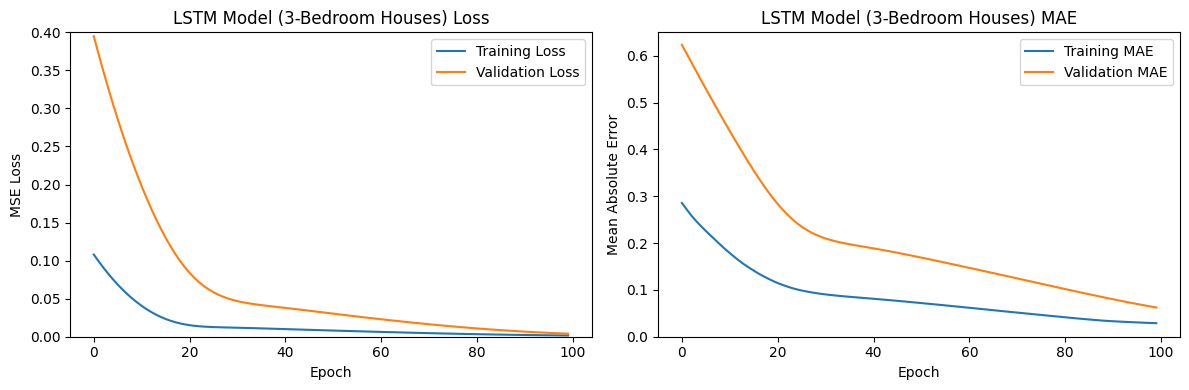

In [ ]:
plot_training_curves(
    history_3bed_lstm,
    "LSTM Model (3-Bedroom Houses)"
)

#### Test Data Evaluation for LSTM Model (3-Bedroom Houses)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
LSTM Model (3-Bedroom Houses) Train RMSE: 9834.58
LSTM Model (3-Bedroom Houses) Test RMSE: 12127.97


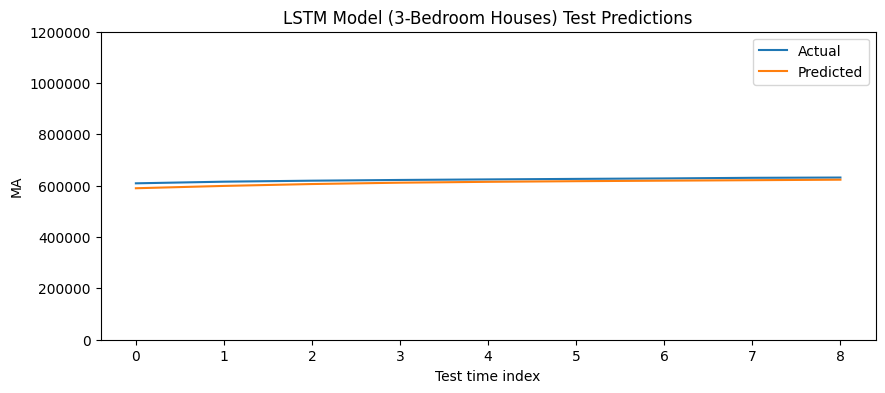

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
LSTM Model (3-Bedroom Houses) RMSE: 12127.97
LSTM Model (3-Bedroom Houses) MAE: 11562.92


In [ ]:
evaluate_and_plot(
    model_3bed_lstm,
    trainX_3bed,
    testX_3bed,
    trainY_3bed,
    testY_3bed,
    scaler_3bed,
    "LSTM Model (3-Bedroom Houses)"
)

lstm_3bed_rmse, lstm_3bed_mae = evaluate_metrics(
    model_3bed_lstm,
    testX_3bed,
    testY_3bed,
    scaler_3bed
)

print(f"LSTM Model (3-Bedroom Houses) RMSE: {lstm_3bed_rmse:.2f}")
print(f"LSTM Model (3-Bedroom Houses) MAE: {lstm_3bed_mae:.2f}")